# DO Card Classifier Training

Train a mask-guided feature-based classifier using data produced by the DO notebooks: reference card crops, augmented card crops (+ saved augmented-card masks), and labeled crops from augmented scenes (+ scene masks).
The notebook saves a single classifier that predicts labels such as `r_5`, `wild`, or `draw_4` directly.

In [11]:
from pathlib import Path
import sys

candidate_src_dirs = [
    Path.cwd() / "src",
    Path.cwd().parent.parent / "src",
]
for src_dir in candidate_src_dirs:
    if src_dir.is_dir():
        parent = src_dir.parent.resolve()
        if str(parent) not in sys.path:
            sys.path.insert(0, str(parent))
        break
else:
    raise FileNotFoundError("Could not locate do/src directory for imports.")


In [12]:
from src.train_classifier import (
    TrainPipelineConfig,
    initialize_training_pipeline,
    plot_sample_preview,
    plot_wrong_predictions,
    run_feature_extraction,
    run_training,
    run_validation_diagnostics,
    save_training_artifacts,
)


## Configuration

In [ ]:
# Most-used quick knobs
SEED = 42
IMG_SIZE = 128
FOURIER_COEFFS = 32
CENTER_CROP_FRACTION = 0.62
MIN_SCENE_BOX_SIDE = 28
MAX_SCENE_BOX_ASPECT = 4.5
VAL_SPLIT = 0.20
BBOX_MARGIN = 0.08

SOURCE_WEIGHTS = {
    "reference": 1.15,
    "augmented_card": 1.0,
    "augmented_scene": 0.75,
}

PREVIEW_COUNT = 12
WRONG_SHOW_COUNT = 16

CFG = TrainPipelineConfig(
    seed=SEED,
    img_size=IMG_SIZE,
    fourier_coeffs=FOURIER_COEFFS,
    center_crop_fraction=CENTER_CROP_FRACTION,
    min_scene_box_side=MIN_SCENE_BOX_SIDE,
    max_scene_box_aspect=MAX_SCENE_BOX_ASPECT,
    val_split=VAL_SPLIT,
    bbox_margin=BBOX_MARGIN,
    source_weights=SOURCE_WEIGHTS,
    preview_count=PREVIEW_COUNT,
    wrong_show_count=WRONG_SHOW_COUNT,
)
CFG

TrainPipelineConfig(seed=42, img_size=128, fourier_coeffs=32, center_crop_fraction=0.62, min_scene_box_side=28, max_scene_box_aspect=4.5, val_split=0.2, bbox_margin=0.08, source_weights={'reference': 1.15, 'augmented_card': 1.0, 'augmented_scene': 0.75}, candidate_settings=[{'n_estimators': 500, 'max_features': 'sqrt', 'min_samples_leaf': 1}, {'n_estimators': 700, 'max_features': 'sqrt', 'min_samples_leaf': 1}, {'n_estimators': 900, 'max_features': 'sqrt', 'min_samples_leaf': 2}, {'n_estimators': 700, 'max_features': 'log2', 'min_samples_leaf': 1}], preview_count=12, wrong_show_count=16)

## Initialize Pipeline

Locate paths, load reference / augmented-card / scene samples with their masks, and assert no test data leaks in (R3).

In [14]:
state = initialize_training_pipeline(CFG)
sorted(state.keys())


Project root: /Users/dorianbesson/EDOC/IA/iapr2026do
Reference labels: /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/object_labels/reference_cards/reference_do.csv
Augmented labels: /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/object_labels/augmented_cards/aug.csv
Scene labels:     /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/object_labels/augmented_scenes/labels.json
Model output:     /Users/dorianbesson/EDOC/IA/iapr2026do/project/models/card_clf_do.pkl
Total samples: 32491
By source: {'reference': 54, 'augmented_card': 5400, 'augmented_scene': 27037}
Classes: 54
Smallest class counts: [('r_8', 577), ('y_7', 574), ('y_1', 573), ('y_skip', 573), ('y_5', 569), ('y_reverse', 563), ('g_3', 561), ('g_5', 547)]
Skipped scene labels: 0
Skipped scene boxes:  0


['card_classes_path',
 'card_clf_path',
 'card_config_path',
 'config',
 'label_counts',
 'missing_files',
 'models_dir',
 'project_root',
 'samples',
 'skipped_scene_boxes',
 'skipped_scene_labels',
 'source_counts']

## Sample Preview

Quick visual check of the mixed training set.

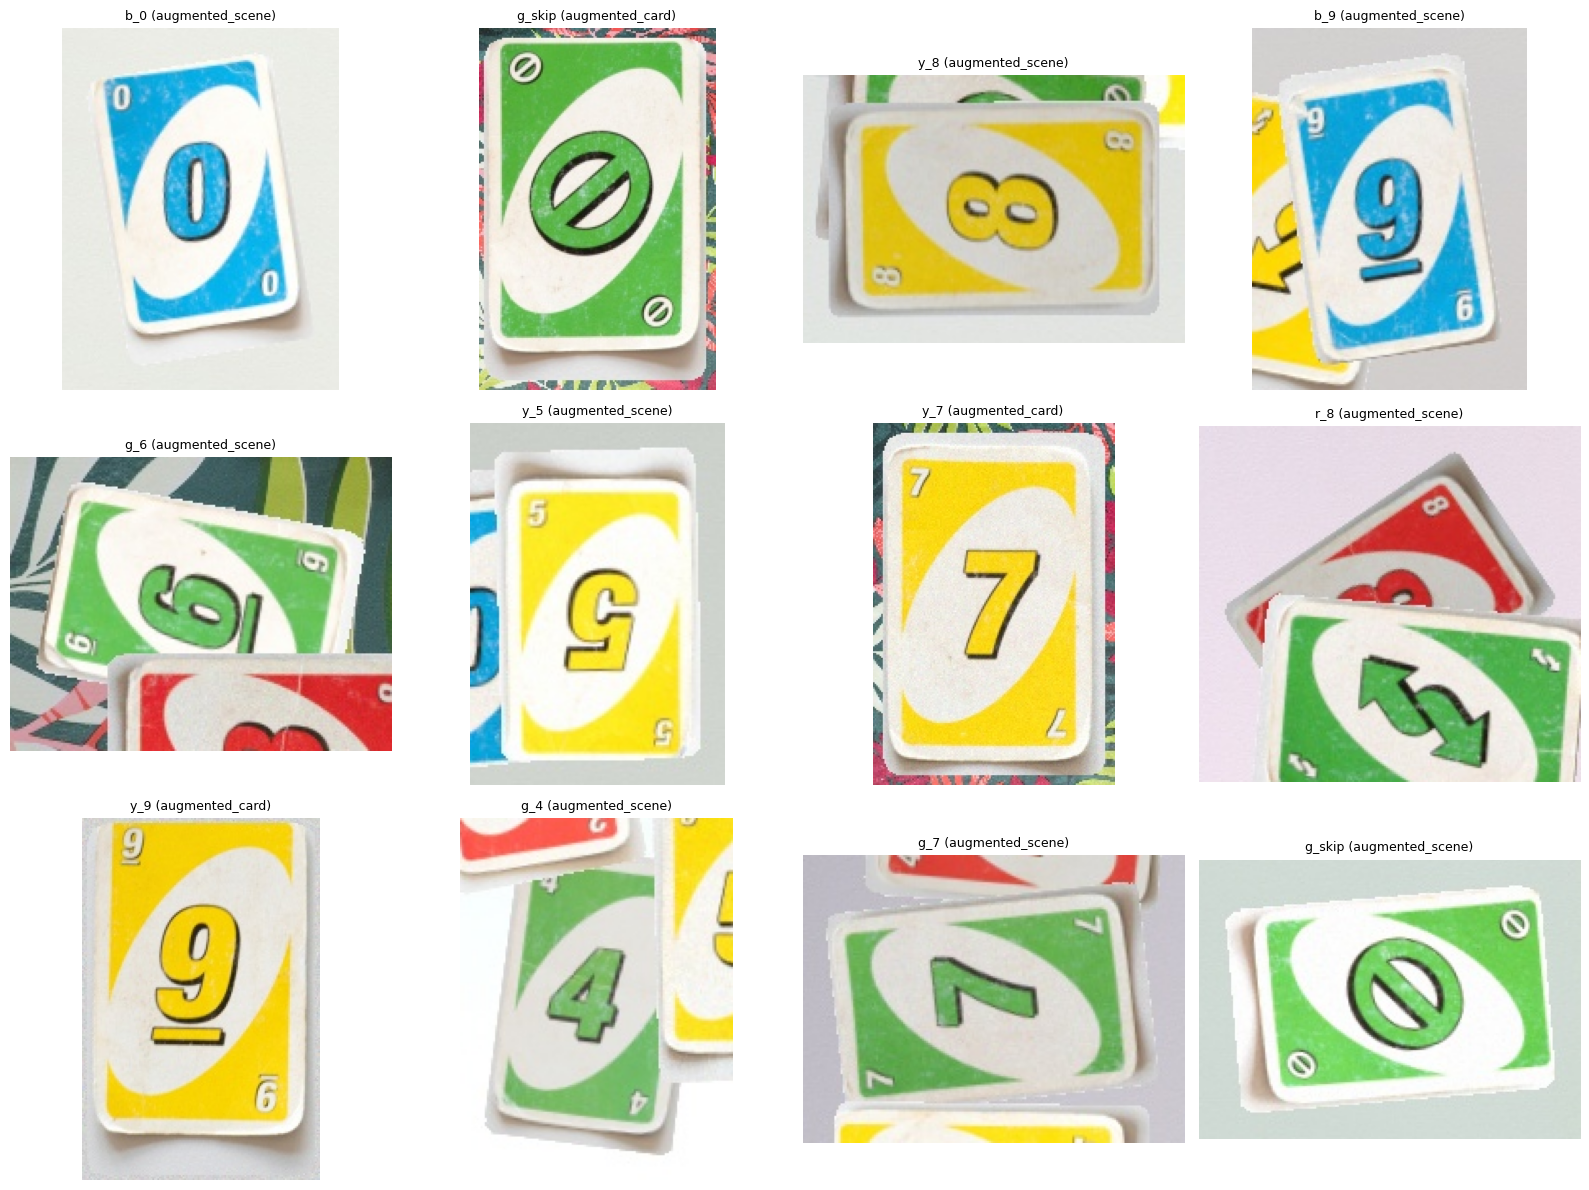

In [15]:
plot_sample_preview(state)


## Feature Extraction

Global HSV histogram + global/center HOG + global/center Fourier descriptors on mask-guided card crops.

In [16]:
state = run_feature_extraction(state)
state["X"].shape, len(state["label_encoder"].classes_)


Extracting features from 32491 samples...
  500/32491
  1000/32491
  1500/32491
  2000/32491
  2500/32491
  3000/32491
  3500/32491
  4000/32491
  4500/32491
  5000/32491
  5500/32491
  6000/32491
  6500/32491
  7000/32491
  7500/32491
  8000/32491
  8500/32491
  9000/32491
  9500/32491
  10000/32491
  10500/32491
  11000/32491
  11500/32491
  12000/32491
  12500/32491
  13000/32491
  13500/32491
  14000/32491
  14500/32491
  15000/32491
  15500/32491
  16000/32491
  16500/32491
  17000/32491
  17500/32491
  18000/32491
  18500/32491
  19000/32491
  19500/32491
  20000/32491
  20500/32491
  21000/32491
  21500/32491
  22000/32491
  22500/32491
  23000/32491
  23500/32491
  24000/32491
  24500/32491
  25000/32491
  25500/32491
  26000/32491
  26500/32491
  27000/32491
  27500/32491
  28000/32491
  28500/32491
  29000/32491
  29500/32491
  30000/32491
  30500/32491
  31000/32491
  31500/32491
  32000/32491
  32491/32491
Feature matrix: (32491, 2212)
Classes (54): [np.str_('b_0'), np.str_

((32491, 2212), 54)

## Train

ExtraTrees classifier with source-aware sample weighting and a tiny hyperparameter sweep.

In [17]:
state = run_training(state)
state["best_params"], state["val_acc"]


Sample weight range: 0.704 - 1.265 (mean=0.792)
[R4] ExtraTreesClassifier has no trainable params; param cap not applicable.
Candidate {'n_estimators': 500, 'max_features': 'sqrt', 'min_samples_leaf': 1} -> val acc 90.95%
Candidate {'n_estimators': 700, 'max_features': 'sqrt', 'min_samples_leaf': 1} -> val acc 90.92%
Candidate {'n_estimators': 900, 'max_features': 'sqrt', 'min_samples_leaf': 2} -> val acc 91.15%
Candidate {'n_estimators': 700, 'max_features': 'log2', 'min_samples_leaf': 1} -> val acc 89.61%
Selected settings: {'n_estimators': 900, 'max_features': 'sqrt', 'min_samples_leaf': 2}
Train samples: 25992 | Val samples: 6499
Train accuracy: 100.0%
Val accuracy:   91.2%


({'n_estimators': 900, 'max_features': 'sqrt', 'min_samples_leaf': 2},
 0.9115248499769195)

## Save Artifacts

In [18]:
state = save_training_artifacts(state)


Saved classifier: /Users/dorianbesson/EDOC/IA/iapr2026do/project/models/card_clf_do.pkl
Saved classes:    /Users/dorianbesson/EDOC/IA/iapr2026do/project/models/card_classes_do.npy
Saved config:     /Users/dorianbesson/EDOC/IA/iapr2026do/project/models/card_classifier_do_config.json


## Validation Diagnostics

              precision    recall  f1-score   support

         b_0       0.87      0.93      0.90       123
         b_1       0.85      0.92      0.88       125
         b_2       0.92      0.94      0.93       128
         b_3       0.92      0.88      0.90       121
         b_4       0.92      0.91      0.92       119
         b_5       0.95      0.87      0.91       122
         b_6       0.92      0.85      0.89       127
         b_7       0.90      0.91      0.90       118
         b_8       0.92      0.88      0.90       124
         b_9       0.98      0.83      0.90       122
    b_draw_2       0.92      0.94      0.93       126
   b_reverse       0.93      0.94      0.93       121
      b_skip       0.92      0.91      0.91       119
      draw_4       0.92      0.93      0.93       119
         g_0       0.85      0.93      0.89       126
         g_1       0.86      0.92      0.89       124
         g_2       0.94      0.95      0.95       125
         g_3       0.94    

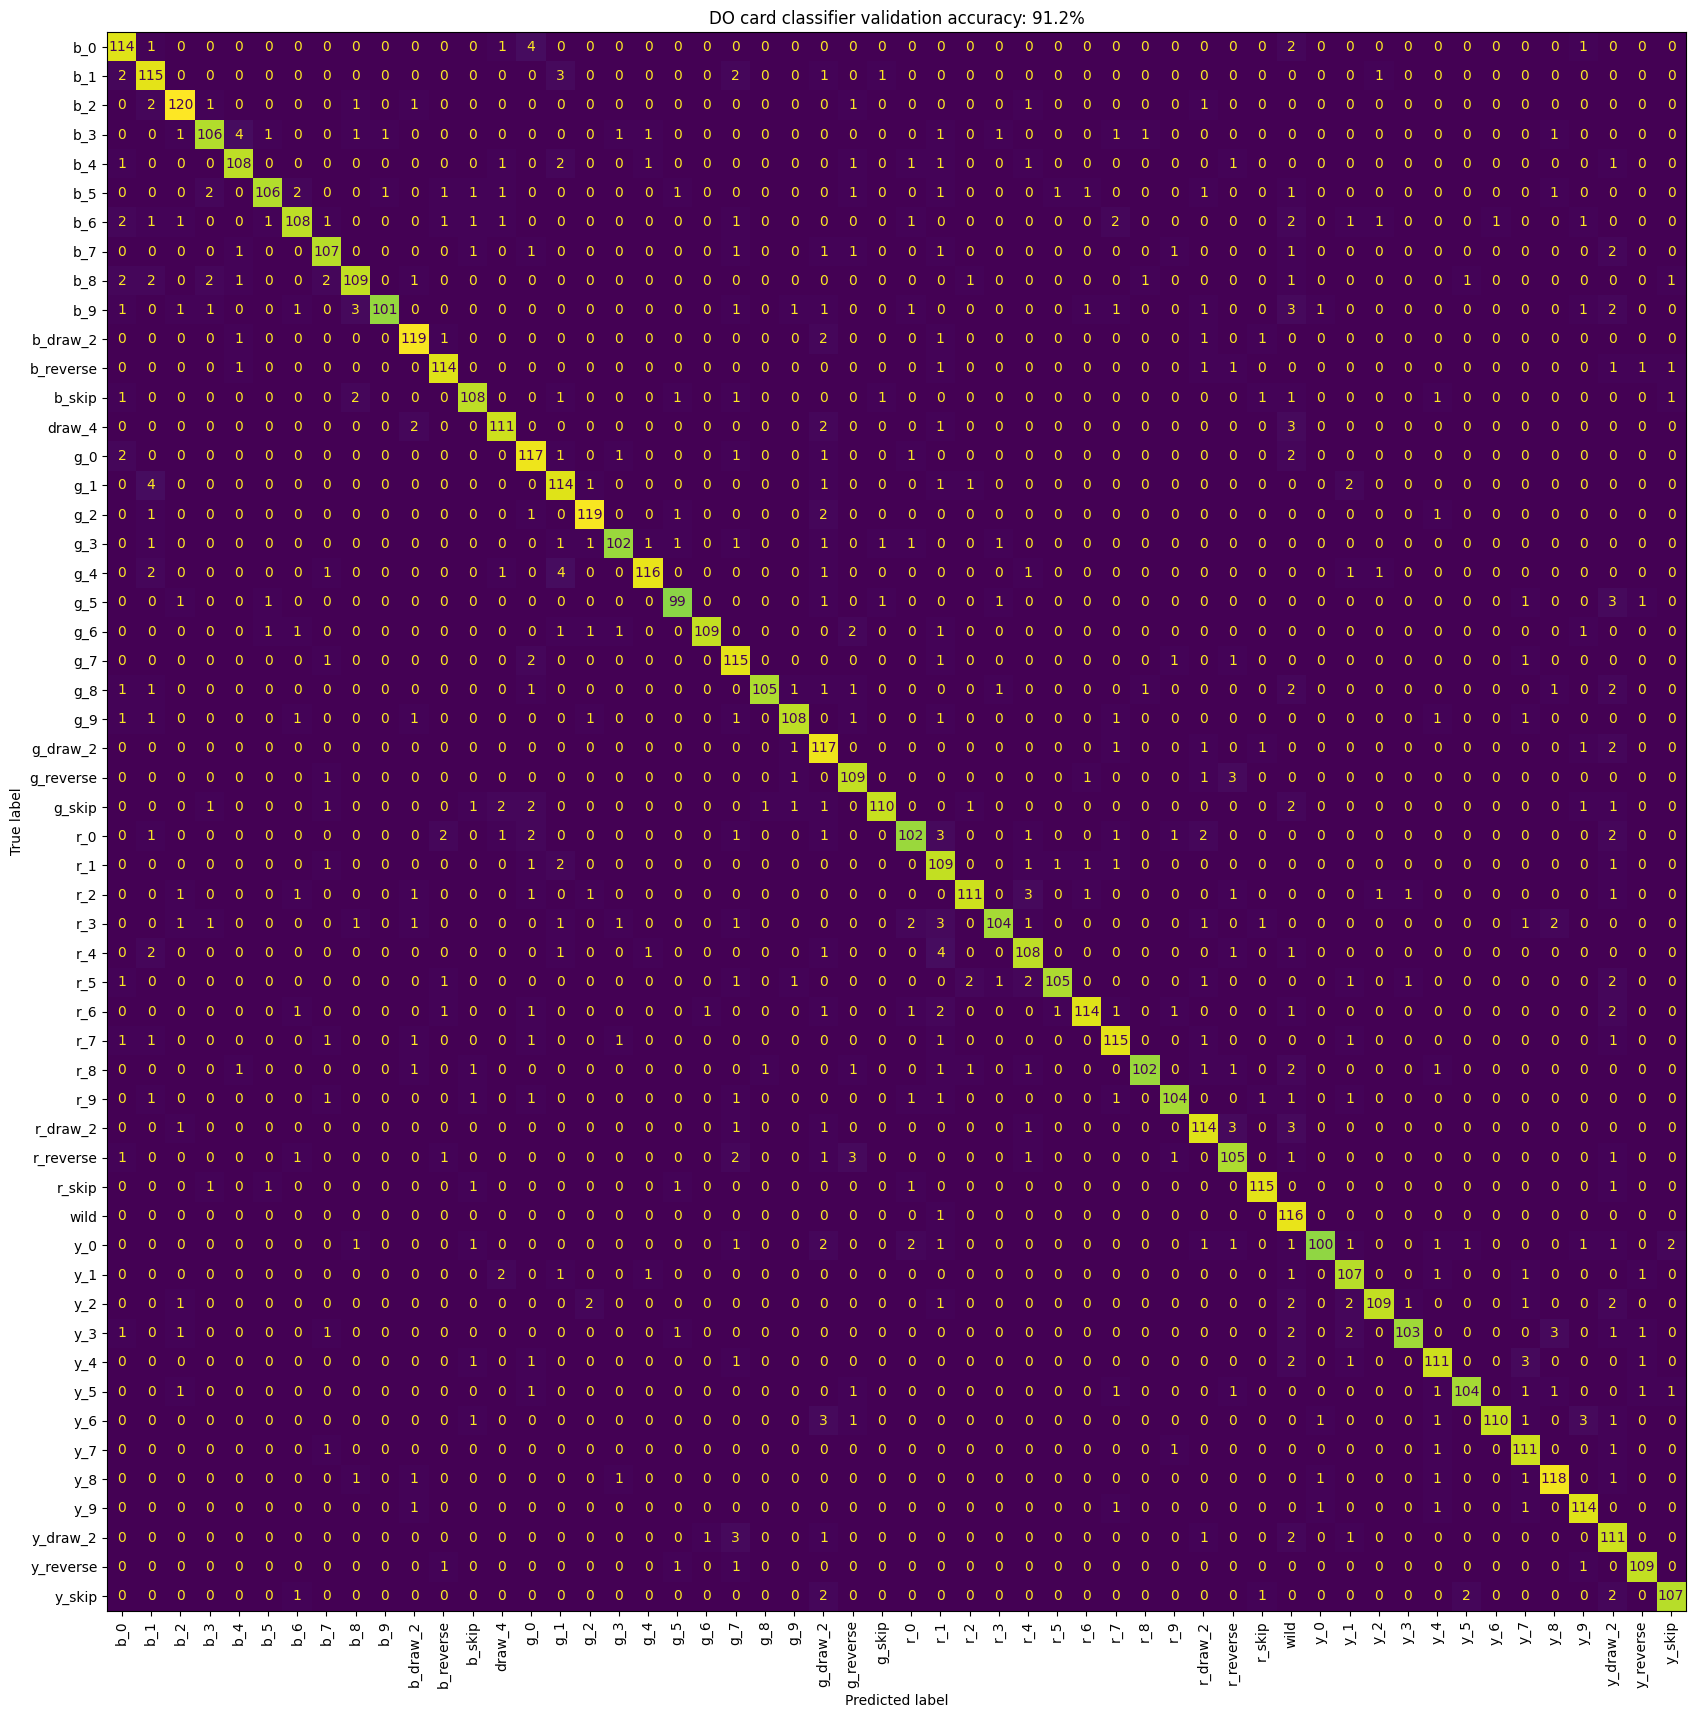

In [19]:
state = run_validation_diagnostics(state)


## Wrong Predictions

Wrong validation predictions: 575 / 6499


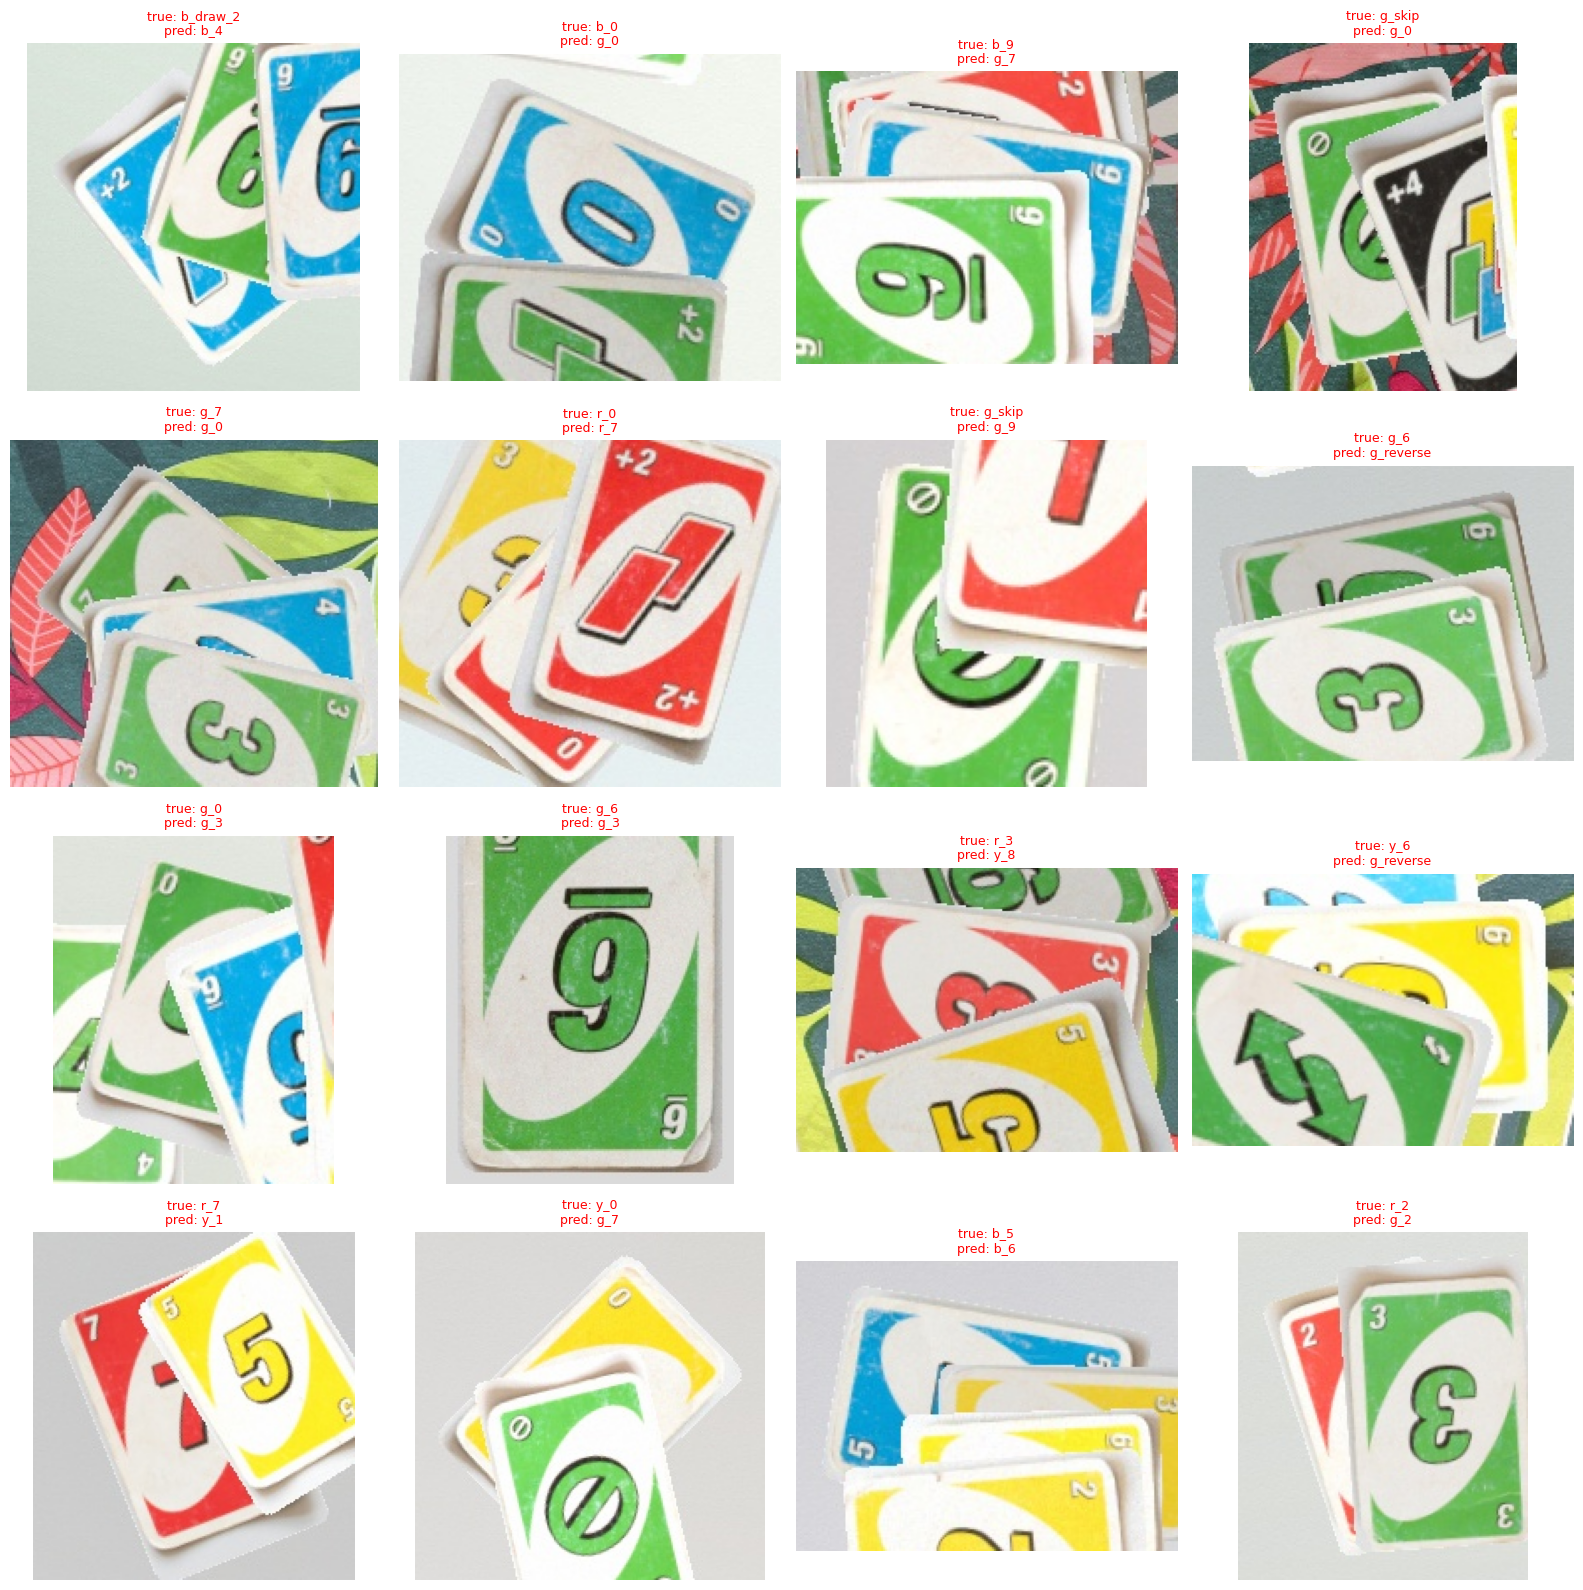

In [20]:
plot_wrong_predictions(state)
